# MÉTODOS NUMÉRICOS
 Aula 4 — Diferenciação Numérica

- Diferenças finitas, Série de Taylor, erro e aplicações de engenharia

**Cursos:** Engenharia Mecânica e Engenharia de Controle e Automação  
**Professor:** Jonatha Costa  
**Ano:** 2026


- Roteiro da aula

| Etapa | Conteúdo |
|---|---|
| 1 | Motivação e aplicações de engenharia |
| 2 | Revisão da derivada |
| 3 | Diferenciação em dados discretos |
| 4 | Diferenças progressiva, regressiva e central |
| 5 | Erro relativo |
| 6 | Implementação em Python |
| 7 | Série de Taylor e erro de truncamento |
| 8 | Fórmulas de maior ordem |
| 9 | Primeira, segunda e terceira derivadas |
| 10 | Aplicações mecânicas e de controle |
| 11 | Laboratórios computacionais |
| 12 | Exercícios |
| 13 | Projeto final |
| 14 | Síntese e avaliação |

> **Metodologia:** conceito → interpretação física → cálculo manual → implementação → experimento computacional → exercício → aplicação.


# Considerações iniciais



## Motivação: por que diferenciar numericamente?

A derivada aparece diretamente em modelos de engenharia.

- Mecânica
    - Variação do espaço $\delta x$ em relação a variação do tempo $\delta t$ 

- Controle e Automação

A taxa de variação de uma variável medida pode ser necessária para:
    
    - análise de dinâmica;
    - identificação de sistemas;
    - processamento de sinais;
    - estimação de estados;
    - implementação de ações derivativas.

- Transferência de calor

    - Gradientes de temperatura aparecem em relações de fluxo de calor.

- Instrumentação

    $
    - (t_0,x_0),(t_1,x_1),\ldots,(t_n,x_n).
    $

Nesse caso, a derivada precisa ser **estimada numericamente**.


## Revisão: significado da derivada

A definição é

$
f'(a)=\lim_{x\rightarrow a}
\frac{f(x)-f(a)}{x-a}.
$

<p style="text-align: center;">
<strong> Figura — Aproximação de derivadas.</strong>
</p>
<p style="text-align: center;">
<img src="figuras/dif3.png" width="400">
</p>
<p style="text-align: center;">
Fonte: Gilat,(2008).
</p>

A derivada representa a inclinação da reta tangente.

Quando $x$ está próximo de $a$,

$
f'(a)\approx
\frac{f(x)-f(a)}{x-a}.
$

A diferenciação numérica parte exatamente dessa ideia e a adapta a pontos discretos.



---

## Pergunta para a turma

Se você recebe apenas:

```text
tempo = [1.0, 1.1, 1.2, 1.3]
posição = [2.0, 2.4, 3.1, 4.0]
```

é possível calcular a velocidade?

**Sim.** Não precisamos necessariamente conhecer a expressão analítica de $x(t)$, tal que $f(x) = y$.


## Visualização geométrica

A ideia fundamental é aproximar a inclinação da tangente pela inclinação de uma secante.

Para dois pontos:

$$
m=
\frac{f(x_2)-f(x_1)}
{x_2-x_1}.
$$

Quanto mais apropriados forem os pontos utilizados, melhor poderá ser a aproximação local.

Conforme apresentado na Figura 1 — Aproximação de derivadas.

<a id="fig:dif2"></a>

<p style="text-align: center;"> <strong>Figura 1 — Aproximação de derivadas.</strong> </p> <p style="text-align: center;"> <img src="figuras/dif2.png" width="400"> </p> <p style="text-align: center;"> Fonte: Gilat (2008). </p>



# Diferenças finitas de primeira derivada

Considere pontos igualmente espaçados utilizando **2 pontos**:

$
x_{i-1},\quad x_i,\quad x_{i+1}
$
em que
$
h=x_{i+1}-x_i=x_i-x_{i-1}.
$

- Progressiva

$
\boxed{
f'(x_i)\approx
\frac{f(x_{i+1})-f(x_i)}{h}
}
$

- Regressiva

$
\boxed{
f'(x_i)\approx
\frac{f(x_i)-f(x_{i-1})}{h}
}
$

- Central

$
\boxed{
f'(x_i)\approx
\frac{f(x_{i+1})-f(x_{i-1})}{2h}
}
$


<a id="fig:dif4"></a>

<p style="text-align: center;"> <strong>Figura 3 — Derivadas numéricas.</strong> </p> <p style="text-align: center;"> <img src="figuras/dif4.png" width="1000"> </p> <p style="text-align: center;"> Fonte: Gilat (2008). </p>

- Regra prática

    * início da tabela → progressiva;
    * fim da tabela → regressiva;
    * interior da tabela → central.

Essa regra será utilizada na implementação para dados discretos.


## Erros do processo

Quando existe um valor de referência:

$
E_r(\%)=
\left|
\frac{Y_{\mathrm{aproximado}}-Y_{\mathrm{real}}}
{Y_{\mathrm{real}}}
\right|100.
$

Também é útil distinguir:

- Erro absoluto

$
E_a=|Y_{\mathrm{aproximado}}-Y_{\mathrm{real}}|.
$

- Erro relativo

$
E_r=
\left|
\frac{Y_{\mathrm{aproximado}}-Y_{\mathrm{real}}}
{Y_{\mathrm{real}}}
\right|.
$

- Erro percentual

$
E_r(\%)=100E_r.
$

## Exemplo 1: $f(x)=x^3$

Considere: $f(x)=x^3.$

Analiticamente: $f'(x)=3x^2$ ==>  $f'(3)=3 \times (3²) = 27.$

Vamos estimar o mesmo valor usando:
- progressiva;
- regressiva;
- central.

Primeiro, com
$x=2,\;3,\;4.$

In [13]:
# Funções de erro
def erro_absoluto(aproximado, real):
    return abs(aproximado - real)

def erro_relativo(aproximado, real):
    return abs((aproximado - real) / real)

def erro_percentual(aproximado, real):
    return 100 * erro_relativo(aproximado, real)


In [14]:
def f(x):
    return x**3

x0 = 3.0
h = 1.0
exata = 27.0

progressiva = ( f(x0+h) - f(x0) )/ h
regressiva = ( f(x0)-f(x0-h) ) / h
central = ( f(x0+h)-f(x0-h) ) / (2*h)

resultados = {
    "Progressiva": progressiva,
    "Regressiva": regressiva,
    "Central": central
}

for metodo, valor in resultados.items():
    print(
        f"{metodo:12s}: {valor:8.4f} | "
        f"erro = {erro_percentual(valor, exata):8.4f}%"
    )


Progressiva :  37.0000 | erro =  37.0370%
Regressiva  :  19.0000 | erro =  29.6296%
Central     :  28.0000 | erro =   3.7037%


# LABORATÓRIOS

## LAB01

- O que acontece se reduzirmos $h$?


,h,P,erro_P,R,erro_R,C,erro_C
0,1.00,37.0000,37.037037,19.0000,29.629630,28.0000,3.703704
1,0.50,31.7500,17.592593,22.7500,15.740741,27.2500,0.925926
2,0.25,29.3125,8.564815,24.8125,8.101852,27.0625,0.231481
3,0.10,27.9100,3.370370,26.1100,3.296296,27.0100,0.037037
4,0.05,27.4525,1.675926,26.5525,1.657407,27.0025,0.009259
5,0.01,27.0901,0.333704,26.9101,0.332963,27.0001,0.000370


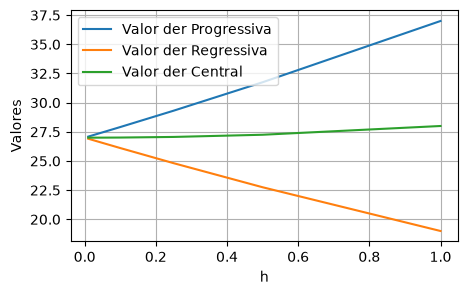

In [15]:
import pandas as pd

#----------------------------------------------
hs = [1.0, 0.5, 0.25, 0.1, 0.05, 0.01]
dados = []
for h in hs:
    p = (f(x0+h)-f(x0))/h
    r = (f(x0)-f(x0-h))/h
    c = (f(x0+h)-f(x0-h))/(2*h)
    dados.append([
        h, 
        p, erro_percentual(p, exata),
        r, erro_percentual(r, exata),
        c, erro_percentual(c, exata)
    ])
#----------------------------------------------

df = pd.DataFrame(dados)
df.columns = ["h", "P", "erro_P", "R", "erro_R", "C", "erro_C"]
display(df)
#----------------------------------------------
# Percepção gráfica da distância entre os erros
plt.figure(figsize=(5, 3))

plt.plot(df.h,df.P, label="Valor der Progressiva")

plt.plot(df.h,df.R, label="Valor der Regressiva")
plt.plot(df.h,df.C, label="Valor der Central")
plt.xlabel("h")
plt.ylabel("Valores")
plt.grid('on')
plt.legend()
plt.show()    

## LAB02

Modifique a função anterior para investigar:
```text
h = 1
h = 0.5
h = 0.25
h = 0.1
h = 0.01
h = 0.001
```

### Responda

1. Qual método converge mais rapidamente neste exemplo?
2. O erro da diferença central diminui aproximadamente com $h^2$?
3. O que você espera acontecer para valores extremamente pequenos de $h$?
4. Qual a diferença entre erro de truncamento e erro de arredondamento?

> A última questão será formalizada mais adiante.


## LAB 03


Considere um sistema massa–mola–amortecedor da figura a abaixo:


<p style="text-align: center;">
<strong>Figura 2 — Sistema massa–mola–amortecedor.</strong>
</p>
<p style="text-align: center;">
<img src="figuras/massa-mola.png" width="400">
</p>
<p style="text-align: center;">
Fonte: Gilat,(2008).
</p>

O experimento fornece a posição do bloco em função do tempo.
$x=x(t)$
A velocidade é $v(t)=x'(t)$ e a aceleração $a(t)=x''(t).$

Dados utilizados no material:

Claro. Para uma apresentação acadêmica, o melhor é **separar as duas grandezas em linhas**, mantendo os valores alinhados e sem deixar a tabela excessivamente larga:

- Dados experimentais

|  $t$ (s) |   4,0 |   4,2 |   4,4 |   4,6 |  4,8 |  5,0 |  5,2 |
| -------: | ----: | ----: | ----: | ----: | ---: | ---: | ---: |
| $x$ (cm) | −5,87 | −4,23 | −2,55 | −0,89 | 0,67 | 2,09 | 3,31 |

|  $t$ (s) |  5,4 |  5,6 |  5,8 |  6,0 |  6,2 |  6,4 |  6,6 |
| -------: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| $x$ (cm) | 4,31 | 5,06 | 5,55 | 5,78 | 5,77 | 5,52 | 5,08 |

|  $t$ (s) |  6,8 |  7,0 |  7,2 |  7,4 |  7,6 |  7,8 |   8,0 |
| -------: | ---: | ---: | ---: | ---: | ---: | ---: | ----: |
| $x$ (cm) | 4,46 | 3,72 | 2,88 | 2,00 | 1,10 | 0,23 | −0,59 |


Para $t=5$s:

$
v(5)=
\frac{x(5,2)-x(4,8)}
{5,2-4,8}
=6,6\;\mathrm{cm/s}.
$

Para $t=6$s:

$
v(6)=
\frac{x(6,2)-x(5,8)}
{6,2-5,8}
=0,55\;\mathrm{cm/s}.
$


v(t=v5s) = 6.60 cm/s
v(t=v6s) = 0.55 cm/s


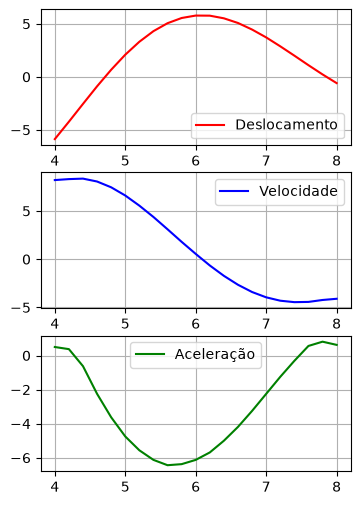

In [6]:
"""
Definindo os valores de x,y e localizando v5 e v6
"""

x = np.array(
[-5.87,-4.23,-2.55,-0.89,0.67,2.09,3.31,4.31,5.06,5.55,5.78,5.77,
5.52,5.08,4.46,3.72,2.88,2.00,1.10,0.23,-0.59])

t= np.array(
[4. , 4.2, 4.4, 4.6, 4.8, 5. , 5.2, 5.4, 5.6, 5.8, 6. , 6.2, 6.4, 
  6.6, 6.8, 7. , 7.2, 7.4, 7.6, 7.8, 8.]) 

dic = {'v5':5.0,
       'v6':6.0}

for nome,tempo in dic.items():
    i = np.where(t==tempo)[0][0] # Localizando o intervalo no array [0][0]
    v = (x[i+1]-x[i-1])/(t[i+1]-t[i-1])
    print(f"v(t={nome}s) = {v:.2f} cm/s")

"""
- Implementação para uma tabela completa

Vamos automatizar a estratégia:

    - primeiro ponto → progressiva;
    - pontos internos → central;
    - último ponto → regressiva.

"""

def derivada_primeira(x, y):
    """Calcula a primeira derivada aproximada de dados discretos."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) != len(y):
        raise ValueError("x e y devem ter o mesmo tamanho.")
    if len(x) < 3:
        raise ValueError("São necessários pelo menos três pontos.")
    if np.any(np.diff(x) == 0):
        raise ValueError("Os valores de x devem ser distintos.")

    dydx = np.empty_like(y)
    # Primeiro ponto: progressiva
    dydx[0] = (y[1]-y[0])/(x[1]-x[0])
    # Pontos internos: central
    for i in range(1, len(x)-1):
        dydx[i] = (y[i+1]-y[i-1])/(x[i+1]-x[i-1])
    # Último ponto: regressiva
    dydx[-1] = (y[-1]-y[-2])/(x[-1]-x[-2])
    
    return dydx

vel,acel = derivada_primeira(t, x), derivada_primeira(t, derivada_primeira(t, x)) 
# ------------------------------------------------

labels=["Deslocamento","Velocidade","Aceleração"]
colors = ['r','b','g']
plt.figure(figsize=(4, 6))
for i,j in enumerate([x,vel,acel]):
    plt.subplot(3,1,i+1)
    plt.plot(t,j,label=labels[i],color=colors[i])
    plt.legend()
    plt.grid(True)

# Série de Taylor — origem das fórmulas de derivação numérica



A **Série de Taylor** é a base teórica para a construção das fórmulas de
derivação numérica. Ela permite representar uma função em torno de um ponto
conhecido por meio de suas derivadas.

Além de fornecer as fórmulas de aproximação, a Série de Taylor permite
identificar os **termos que são desprezados** durante a aproximação e,
consequentemente, determinar a **ordem do erro de truncamento**.

## Fórmula geral da Série de Taylor

A Série de Taylor de uma função $f(x)$ em torno de um ponto $x_i$ pode ser
escrita na forma geral

$$
\boxed{
f(x)=
\sum_{k=0}^{\infty}
\frac{f^{(k)}(x_i)}{k!}
(x-x_i)^k
}
$$

em que:

- $f^{(k)}(x_i)$ representa a $k$-ésima derivada de $f$ avaliada em $x_i$;
- $k!$ é o fatorial de $k$;
- $(x-x_i)^k$ representa a potência do deslocamento em relação ao ponto
  $x_i$.

Expandindo o somatório, obtemos

$$
f(x)=
f(x_i)
+
f'(x_i)(x-x_i)
+
\frac{f''(x_i)}{2!}(x-x_i)^2
+
\frac{f'''(x_i)}{3!}(x-x_i)^3
+\cdots.
$$

A ideia fundamental é que a função pode ser representada por uma sequência
de termos associados a potências crescentes do deslocamento $(x-x_i)$.

---

- Aplicação para $x=x_i+h$

Na derivação numérica, consideramos

$$
h=x_{i+1}-x_i,
$$

de modo que

$$
x_{i+1}=x_i+h.
$$

Substituindo $x=x_i+h$ na Série de Taylor,

$$\boxed{f(x_i+h)=
\sum_{k=0}^{\infty}
\frac{f^{(k)}(x_i)}{k!}h^k
}
$$

ou, explicitamente,

$$\boxed{
f(x_i+h)
=f(x_i)
+
f'(x_i)h
+
\frac{f''(x_i)}{2!}h^2
+
\frac{f'''(x_i)}{3!}h^3
+\cdots
}
$$

Como $x_i+h=x_{i+1}$, podemos escrever

$$f(x_{i+1})=f(x_i)
+
f'(x_i)h
+
\frac{f''(x_i)}{2!}h^2
+
\frac{f'''(x_i)}{3!}h^3
+\cdots.
$$

Observe que os termos aparecem em potências crescentes de $h$:

$$
h,\qquad h^2,\qquad h^3,\qquad h^4,\ldots
$$

Essa estrutura será fundamental para determinar a ordem da aproximação.

---

- Isolando a primeira derivada e reorganizando a expressão, temos:

$$f'(x_i)h=f(x_{i+1})-f(x_i) - \frac{f''(x_i)}{2!}h^2 - \frac{f'''(x_i)}{3!}h^3
-\cdots.
$$

Dividindo por $h$,

$$ f'(x_i) = \frac{f(x_{i+1})-f(x_i)}{h}
- \frac{f''(x_i)}{2!}h
- \frac{f'''(x_i)}{3!}h^2
-\cdots.
$$

Podemos separar essa expressão em duas partes:

$$ \boxed{
f'(x_i)
= \underbrace{
\frac{f(x_{i+1})-f(x_i)}{h}
}_{\text{aproximação numérica}}
+
\underbrace{
\left(
-\frac{f''(x_i)}{2!}h
-\frac{f'''(x_i)}{3!}h^2
-\cdots
\right)
}_{\text{correção/erro}}
}
$$

Nesse ponto, é importante observar que os termos de correção não são
simplesmente ignorados. Eles representam o erro introduzido ao truncar a
Série de Taylor. Como o primeiro termo desprezado é proporcional a $h$,
podemos escrever

$$f'(x_i)
=\frac{f(x_{i+1})-f(x_i)}{h}
+
O(h),
$$

em que $O(h)$ representa um erro cujo comportamento é proporcional a $h$
quando $h\to0$.
Portanto, quanto menor for $h$, menor tende a ser o erro de
truncamento, desde que as demais fontes de erro sejam desconsideradas.

Assim, para obter uma fórmula prática de diferenciação numérica, truncamos
a expansão após o primeiro termo e utilizamos apenas a parcela principal da
aproximação:

Se desprezarmos os termos de correção, obtemos

$$
\boxed{
f'(x_i)
\approx
\frac{f(x_{i+1})-f(x_i)}{h}
}
$$

Essa expressão é conhecida como **fórmula da diferença progressiva** para
a primeira derivada.

Note que isto não é uma igualdade em $f(x)$, mas uma aproximação em $f(x)$ contendo um erro de trucamento de ordem conhecida.

## Erro de truncamento

O erro de truncamento surge porque, ao construir a fórmula numérica,
**desprezamos os termos restantes da Série de Taylor**.

Para a diferença progressiva,

$$ f'(x_i) = \frac{f(x_{i+1})-f(x_i)}{h}
- \frac{f''(x_i)}{2!}h
- \frac{f'''(x_i)}{3!}h^2
-\cdots.
$$

Definindo o erro como

$$ E_T
= f'(x_i)
- \frac{f(x_{i+1})-f(x_i)}{h},
$$

obtemos

$$ E_T = -\frac{f''(x_i)}{2!}h
-\frac{f'''(x_i)}{3!}h^2
-\cdots.
$$

Como os termos a partir de $h^2$ são de ordem superior, podemos representar
essa parte por $O(h^2)$. Assim,

$$ \boxed{ E_T = -\frac{f''(x_i)}{2}h
+
O(h^2)
}
$$


---

- Qual o significado de $O(h^2)$?

A notação

$$
O(h^2)
$$

não significa que os termos restantes sejam exatamente iguais a $h^2$.

Ela indica que esses termos possuem comportamento de ordem $h^2$ ou
superior. Por exemplo,

$$
3h^2+5h^3+7h^4
$$

pode ser representado por

$$
O(h^2).
$$

Portanto, a expressão

$$
E_T
= -\frac{f''(x_i)}{2}h
+
O(h^2)
$$

pode ser entendida, de forma simplificada, como

$$
E_T
= C_1h+C_2h^2+C_3h^3+\cdots,
$$

em que
$$
C_1=-\frac{f''(x_i)}{2}.
$$

---

- Qual termo determina a ordem do erro?

Na expressão

$$ E_T = -\frac{f''(x_i)}{2}h
+
O(h^2),
$$

temos:

$$
\underbrace{
-\frac{f''(x_i)}{2}h
}_{\text{termo de ordem }h}
+
\underbrace{
O(h^2)
}_{\text{termos de ordem }h^2\text{ ou superior}}.
$$

Para $h$ suficientemente pequeno,

$$
h^2\ll h.
$$

Por exemplo, para

$$
h=0.1,
$$

temos

$$
h=0.1,
\qquad
h^2=0.01.
$$

Para

$$
h=0.01,
$$

temos

$$
h=0.01,
\qquad
h^2=0.0001.
$$

Portanto, quando $h\rightarrow0$, os termos contendo $h^2$, $h^3$, etc.
diminuem mais rapidamente que o termo contendo $h$.

Assim, o comportamento dominante do erro é determinado por

$$
-\frac{f''(x_i)}{2}h.
$$

Consequentemente,

$$
\boxed{
E_T=O(h)
}
$$

---

- Ordem do método

De forma geral, se o erro de truncamento possui a forma

$$ E_T=C h^p
+
O(h^{p+1}),
$$

com $C\neq0$, então o primeiro termo não nulo do erro é proporcional a
$h^p$.

Nesse caso, dizemos que o método é de **ordem $p$**.

Portanto:

$$
\boxed{
\begin{aligned}
E_T=O(h)
&\quad\Rightarrow\quad
\text{método de primeira ordem}
\\[4pt]
E_T=O(h^2)
&\quad\Rightarrow\quad
\text{método de segunda ordem}
\\[4pt]
E_T=O(h^3)
&\quad\Rightarrow\quad
\text{método de terceira ordem}
\end{aligned}
}
$$

No caso da diferença progressiva,

$$ E_T = -\frac{f''(x_i)}{2}h + O(h^2),
$$

o primeiro termo não nulo é proporcional a $h$.

Logo,

$$
\boxed{
E_T=O(h)
}
$$

e a fórmula de diferença progressiva é um método de

$$
\boxed{\text{primeira ordem}.}
$$


- Consequência prática da primeira ordem

A ordem do método também permite prever como o erro se comporta quando
reduzimos o passo $h$.

Para um método de primeira ordem,

$$
E_T=O(h),
$$

podemos interpretar, aproximadamente, que

$$
E_T\propto h.
$$

Se o passo for reduzido pela metade,

$$ h_{\mathrm{novo}} = \frac{h_{\mathrm{antigo}}}{2},
$$

esperamos aproximadamente

$$
E_{\mathrm{novo}}
\approx
\frac{1}{2}E_{\mathrm{antigo}}.
$$

Portanto,

$$
\boxed{
h\rightarrow\frac{h}{2}
\quad\Longrightarrow\quad
E\rightarrow\frac{E}{2}
}
$$

aproximadamente.

Para comparação, em um método de segunda ordem,

$$
E_T=O(h^2),
$$

a redução do passo pela metade produziria aproximadamente

$$ E_{\mathrm{novo}} \approx \left(\frac{1}{2}\right)^2 E_{\mathrm{antigo}}
= \frac14E_{\mathrm{antigo}}.
$$

Assim:

| Ordem do método | Erro | Se $h$ for reduzido pela metade |
|:---:|:---:|:---:|
| 1ª ordem | $O(h)$ | erro $\approx E/2$ |
| 2ª ordem | $O(h^2)$ | erro $\approx E/4$ |
| 3ª ordem | $O(h^3)$ | erro $\approx E/8$ |
| 4ª ordem | $O(h^4)$ | erro $\approx E/16$ |

Quanto maior a ordem, mais rapidamente o erro diminui com a redução de $h$.

---

- Interpretação final

A Série de Taylor permite compreender duas conceitos fundamentais na derivação
numérica:

1. **a origem da fórmula de aproximação da derivada**;
2. **a origem e a ordem do erro de truncamento**.

Para a diferença progressiva,

$$
\boxed{
f'(x_i)
\approx
\frac{f(x_{i+1})-f(x_i)}{h}
}
$$

a aproximação é obtida ao desprezarmos os termos restantes da Série de
Taylor.

O erro possui a estrutura

$$
\boxed{
E_T = -\frac{f''(x_i)}{2}h
+
O(h^2)
}
$$

O termo dominante é

$$
-\frac{f''(x_i)}{2}h,
$$

pois é o primeiro termo não nulo e possui a menor potência de $h$.

Assim,

$$
\boxed{
E_T=O(h)
}
$$

e concluímos que

$$
\boxed{
\text{a diferença progressiva é um método de primeira ordem.}
}
$$

> **Ideia central**
>
> O primeiro termo não nulo do erro determina a ordem do método.
>
> Se
>
> $$
> E_T=C h^p+O(h^{p+1}),
> $$
>
> então o método é de **ordem $p$**.
>
> Para a diferença progressiva,
>
> $$
> E_T=
> -\frac{f''(x_i)}{2}h+O(h^2),
> $$
>
> portanto,
>
> $$
> \boxed{E_T=O(h)}
> $$
>
> e o método é de **primeira ordem**.

- Ordem de precisão

Para as aproximações básicas:

| Fórmula | Ordem |
|---|---:|
| Progressiva — 2 pontos | $O(h)$ |
| Regressiva — 2 pontos | $O(h)$ |
| Central — 3 pontos | $O(h^2)$ |

Consequência:

Se $h$ for reduzido aproximadamente pela metade, espera-se, idealmente:

- método $O(h)$ → erro aproximadamente dividido por 2;
- método $O(h^2)$ → erro aproximadamente dividido por 4;
- método $O(h^4)$ → erro aproximadamente dividido por 16.

Essa é uma forma prática de reconhecer a ordem de convergência.


# Fórmulas de maior ordem utilizando Taylor


## Primeira derivada
```
Confira a dedução do material textual indicados na bibliografia.

```


- Progressiva com 3 pontos

$
f'(x_i)\approx
\frac{-3f(x_i)+4f(x_{i+1})-f(x_{i+2})}{2h}
\qquad O(h^2)
$

- Regressiva com 3 pontos

$
f'(x_i)\approx
\frac{f(x_{i-2})-4f(x_{i-1})+3f(x_i)}{2h}
\qquad O(h^2)
$

- Central com 5 pontos

$
f'(x_i)\approx
\frac{f(x_{i-2})-8f(x_{i-1})+8f(x_{i+1})-f(x_{i+2})}{12h}
\qquad O(h^4)
$


## Segunda derivada

- Central com 3 pontos

$
\boxed{
f''(x_i)\approx
\frac{f(x_{i-1})-2f(x_i)+f(x_{i+1})}{h^2}
}
\qquad O(h^2)
$

- Central com 5 pontos

$
\boxed{
f''(x_i)\approx
\frac{-f(x_{i-2})+16f(x_{i-1})-30f(x_i)+16f(x_{i+1})-f(x_{i+2})}
{12h^2}
}
\qquad O(h^4)
$


## Terceira derivada

- Central com 4 pontos

$
f'''(x_i)\approx
\frac{-f(x_{i-2})+2f(x_{i-1})-2f(x_{i+1})+f(x_{i+2})}
{2h^3}
\qquad O(h^2)
$

- Central com 6 pontos

$
f'''(x_i)\approx
\frac{
f(x_{i-3})-8f(x_{i-2})+13f(x_{i-1})
-13f(x_{i+1})+8f(x_{i+2})-f(x_{i+3})
}{8h^3}
\qquad O(h^4)
$


# Exemplos

## primeira derivada

Para  $ f(x)=x^3 $ ==> $ f'(3)=27$, analiticamente.

Com três pontos $3, 4, 5$ ==> $f'(3)\approx 25.$

Erro: $E_r\approx7,4\%.$

Com os pontos $3,\;3.25,\;3.5$ ==> $f'(3)\approx 26.875$ e o erro cai para aproximadamente: $0,46\%.$


In [7]:
def primeira_progressiva_2p(f, x, h):
    ''' Derivada progressiva com 2 pontos'''
    return (f(x+h)-f(x))/h


def primeira_progressiva_3p(f, x, h):
    ''' Derivada progressiva com 3 pontos'''
    return (-3*f(x)+4*f(x+h)-f(x+2*h))/(2*h)

lista_valores=[]

for h in np.arange(1,0,-0.01):
    valor3 = primeira_progressiva_3p(f, 3.0, h)
    valor2 = primeira_progressiva_2p(f, 3.0, h)
    lista_valores.append([h,valor3,erro_percentual(valor3,27),valor2,erro_percentual(valor2,27), ])

df = pd.DataFrame(lista_valores)
df.columns = ["h", "Aprox.3p", "erro_3P","Aprox.2p", "erro_2",]
df

,h,Aprox.3p,erro_3P,Aprox.2p,erro_2
0,1.00,25.0000,7.407407,37.0000,37.037037
1,0.99,25.0398,7.260000,36.8901,36.630000
2,0.98,25.0792,7.114074,36.7804,36.223704
3,0.97,25.1182,6.969630,36.6709,35.818148
4,0.96,25.1568,6.826667,36.5616,35.413333
...,...,...,...,...,...
95,0.05,26.9950,0.018519,27.4525,1.675926
96,0.04,26.9968,0.011852,27.3616,1.339259
97,0.03,26.9982,0.006667,27.2709,1.003333
98,0.02,26.9992,0.002963,27.1804,0.668148


## segunda derivada

Considere: $f(x)=\frac{2^x}{x}.$

$
f''(2)\approx0,5746.
$

Pela diferença central de três pontos:

$
f''(x_i)\approx
\frac{f(x_i-h)-2f(x_i)+f(x_i+h)}
{h^2}.
$

O exemplo considera $h=0,2$ e $h=0,1$.


In [8]:
valor_real = 0.5746

def f_exp(x):
    return 2**x/x

def segunda_central_3p(f, x, h):
    return (f(x-h)-2*f(x)+f(x+h))/h**2

dados=[]
for h in np.arange(0.5,0.1,-0.05):
    valor = segunda_central_3p(f_exp, 2.0, h)
    dados.append([h,valor,erro_percentual(valor,valor_real)])
    
df = pd.DataFrame(dados)
df.columns=["h","valor","erro %"]
df

,h,valor,erro %
0,0.50,0.593439,3.278652
1,0.45,0.589692,2.626532
2,0.40,0.586410,2.055299
3,0.35,0.583567,1.560558
4,0.30,0.581143,1.138624
5,0.25,0.579119,0.786443
6,0.20,0.577482,0.501527
7,0.15,0.576220,0.281902


## Estudo experimental da convergência

Agora vamos sair do cálculo manual.

Considere:

$
f(x)=e^x,\qquad x_0=1.
$

A solução exata é:

$
f'(1)=e.
$

Compare:

1. progressiva de 2 pontos — $O(h)$;
2. central — $O(h^2)$;
3. progressiva de 3 pontos — $O(h^2)$;
4. central de 5 pontos — $O(h^4)$.

Teste diferentes valores de $h$ e observe a evolução do erro.


In [9]:
def prog_2p(f, x, h):
    return (f(x+h)-f(x))/h

def cent_3p(f, x, h):
    return (f(x+h)-f(x-h))/(2*h)

def prog_3p(f, x, h):
    return (-3*f(x)+4*f(x+h)-f(x+2*h))/(2*h)

def cent_5p(f, x, h):
    return (f(x-2*h)-8*f(x-h)+8*f(x+h)-f(x+2*h))/(12*h)

func = np.exp
x0 = 1.0
exata = np.e
hs = [1e-1, 5e-2, 1e-2, 5e-3, 1e-3, 5e-4]

dados = []
for h in hs:
    valores = [
        prog_2p(func,x0,h),
        cent_3p(func,x0,h),
        prog_3p(func,x0,h),
        cent_5p(func,x0,h)]
    erros = [erro_percentual(v,exata) for v in valores]
    dados.append([h]+ erros)  # Lista somada a listas  
    
df = pd.DataFrame(
    dados,columns=["h", "prog_2p", "cent_3p", "prog_3p", "cent_5p"])
df

,h,prog_2p,cent_3p,prog_3p,cent_5p
0,0.1000,5.170918,0.166750,0.359543,3.337304e-04
1,0.0500,2.542193,0.041672,0.086533,2.083953e-05
2,0.0100,0.501671,0.001667,0.003358,3.333315e-08
3,0.0050,0.250417,0.000417,0.000836,2.085810e-09
4,0.0010,0.050017,0.000017,0.000033,1.480144e-11
5,0.0005,0.025004,0.000004,0.000008,2.297000e-11


# Erro de truncamento × erro de arredondamento

A análise numérica não termina no erro de truncamento.

Ao reduzir $h$:

- o **erro de truncamento** tende a diminuir;
- operações com números muito próximos podem aumentar o efeito do **erro de arredondamento**.

Assim, existe uma região em que reduzir $h$ deixa de ser vantajoso.

Para dados experimentais existe ainda:

$
\boxed{\text{ruído de medição}}
$

e a diferenciação pode amplificá-lo.

- Consequência prática

Não devemos concluir:

> “quanto menor $h$, sempre melhor”.

A escolha de $h$ é um problema numérico e experimental.


# Exercícios extras


## Exercício 1 — função analítica

Considere:

$
f(x)=x^3+2x.
$

Calcule $f'(2)$ por:

- progressiva;
- regressiva;
- central;

para $h=0,1$.

Depois repita para $h=0,5,\;0,1,\;0,01$.

- Entrega

Uma tabela:

| $h$ | Método | Aproximação | Erro (%) |
|---:|---|---:|---:|

- Questão

Qual método apresenta a menor sensibilidade ao espaçamento neste experimento?


In [10]:
# EXERCÍCIO 1 — complete
def f_ex1(x):
    return x**3 + 2*x

x0 = 2.0
h = 0.1

# TODO
# p = ...
# r = ...
# c = ...
# exata = ...


## Exercício 2 — posição, velocidade e aceleração

Use os dados:

| $t$ (s) | $x$ (mm) |
|---:|---:|
| 0,0 | 0,0 |
| 0,1 | 1,2 |
| 0,2 | 4,5 |
| 0,3 | 9,1 |
| 0,4 | 15,8 |
| 0,5 | 24,0 |

Calcule:

1. $v(t)$;
2. $a(t)$;
3. o instante de maior velocidade;
4. o instante de maior aceleração.

Faça gráficos de $x(t)$, $v(t)$ e $a(t)$.


## Exercício 3 — ordem do método

Para

$
f(x)=e^x,\quad x=1,
$

compare as quatro fórmulas:

- $O(h)$;
- $O(h^2)$;
- $O(h^2)$;
- $O(h^4)$.

Construa uma tabela e um gráfico do erro em função de $h$.

- Questão conceitual

Por que um método de maior ordem não é automaticamente a melhor escolha para qualquer conjunto de dados experimentais?
